# SARIMAX Forecasting Playground

This notebook provides an interactive environment to test the cluster-based SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) model.

### Key Features
- **Dual-Mode Pipeline**: Support for both `long_term` (weather-only) and `day_ahead` (lag-enriched) forecasting.
- **Seasonality Analysis**: ACF/PACF plots and decomposition to validate model parameters.
- **Modular Architecture**: Uses decoupled functions from `src/models/sarimax_model.py`.
- **Performance Optimization**: Aggregates data by cluster to ensure efficient training.

## 0. Environment Setup

Resolve project-level modules from the `src` directory and load the necessary forecasting functions.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized SARIMAX functions
from src.models.sarimax_model import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_sarimax_artifacts
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

print("Setup complete. Local SARIMAX modules loaded from src/.")

✅ Setup complete. Local SARIMAX modules loaded from src/.


## 1. Global Data Loading

We load the global processed dataset once.

In [2]:
dataset_path = os.path.join(PROJECT_ROOT, 'Datasets', 'processed_electricity_data.parquet')
df_long = load_processed_data(dataset_path)

print(f"\n Total observations loaded: {len(df_long):,}")

Loading processed data...

 Total observations loaded: 41,548,234


## 2. Seasonality & Autocorrelation Analysis

To justify our Choice of SARIMAX parameters $(p, d, q) \times (P, D, Q, s)$, we analyze the average profile of Cluster 0. We expect strong autocorrelation at 24h intervals (96 intervals of 15min).

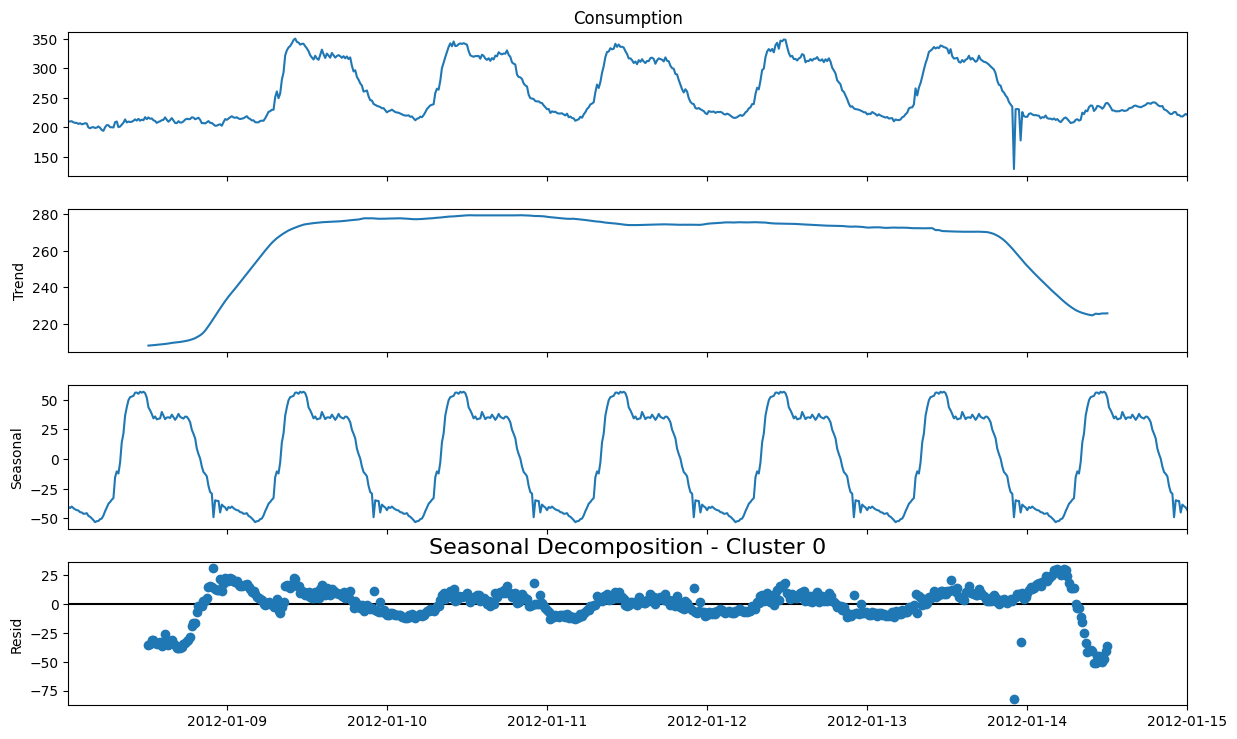

In [3]:
# Aggregating average profile for Cluster 0
cluster_0_profile = (
    df_long[df_long['Cluster'] == 0]
    .groupby('Date')['Consumption'].mean()
    .sort_index()
    .asfreq('15min')
    .ffill()
)

# 1. Seasonal Decomposition (looking at a 1-week window for clarity)
result = seasonal_decompose(cluster_0_profile[:96*7], model='additive', period=96)
fig = result.plot()
fig.set_size_inches(14, 8)
plt.title("Seasonal Decomposition - Cluster 0", fontsize=16)
plt.show()

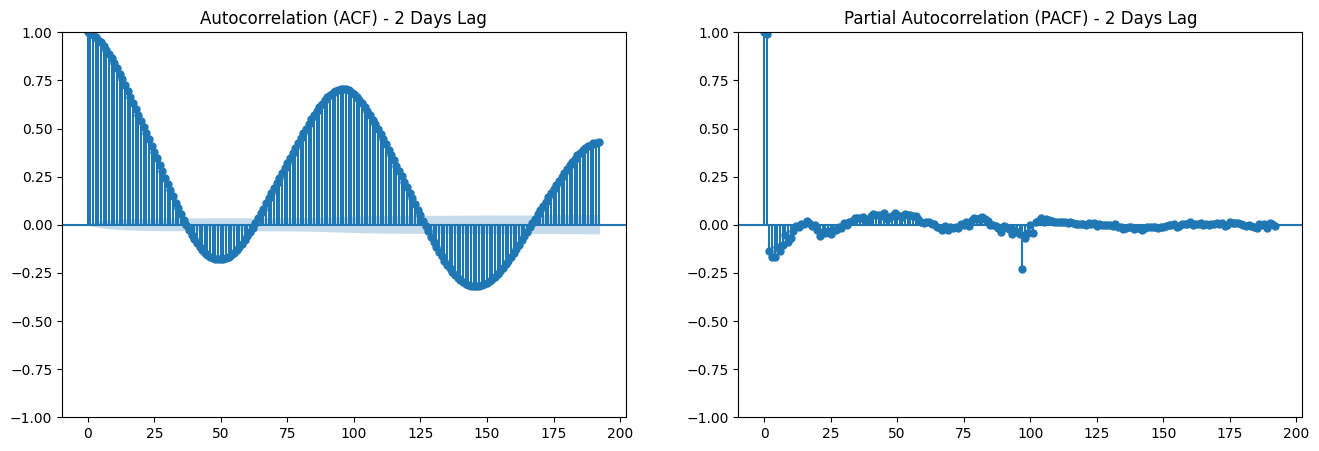

In [4]:
# 2. ACF and PACF Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(cluster_0_profile, lags=96*2, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF) - 2 Days Lag")

plot_pacf(cluster_0_profile, lags=96*2, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF) - 2 Days Lag")

plt.show()

## 3. Long-Term Horizon

This mode benchmarks the model's ability to predict load based strictly on seasonal trends and weather signals, without the benefit of recent consumption history.

In [5]:
# A.1 Prepare Data (Long Term)
train_agg_lt, test_agg_lt, test_raw_lt, scalers_lt, sw_lt, regs_lt = preprocess_and_split(df_long, mode='long_term')

# A.2 Train Cluster Models (takes a few minutes)
models_lt = train_models(train_agg_lt, regs_lt)

# A.3 Predict & Un-scale
results_lt = predict_models(models_lt, test_agg_lt, test_raw_lt, scalers_lt, regs_lt)

# A.4 Evaluate
eval_lt, summary_lt = evaluate_models(results_lt)
display(summary_lt)

# Save Artifacts
save_sarimax_artifacts(models_lt, scalers_lt, sw_lt, regs_lt, mode='long_term')

Preparing train/test split and scaling (Mode: LONG_TERM)...
Scaling individual clients (preventing leakage)...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 56.04it/s]


Aggregating data by Cluster for SARIMAX training...
Training SARIMAX models for 5 clusters...


Training: 100%|██████████| 5/5 [08:18<00:00, 99.66s/it] 


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:04<00:00, 86.87it/s] 



Evaluating Portfolio Performance...

--- SARIMAX PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               94.00            87.40
1.0               81.95            74.48
2.0               99.35            99.12
3.0              155.58           151.99
4.0               93.07            92.87

Global Portfolio MAPE:  104.79%
Global Portfolio WMAPE: 99.71%


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,94.00,87.40
1.0,81.95,74.48
2.0,99.35,99.12
3.0,155.58,151.99
4.0,93.07,92.87



 SARIMAX (long_term) artifacts successfully saved to: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/sarimax_cluster_long_term.pkl


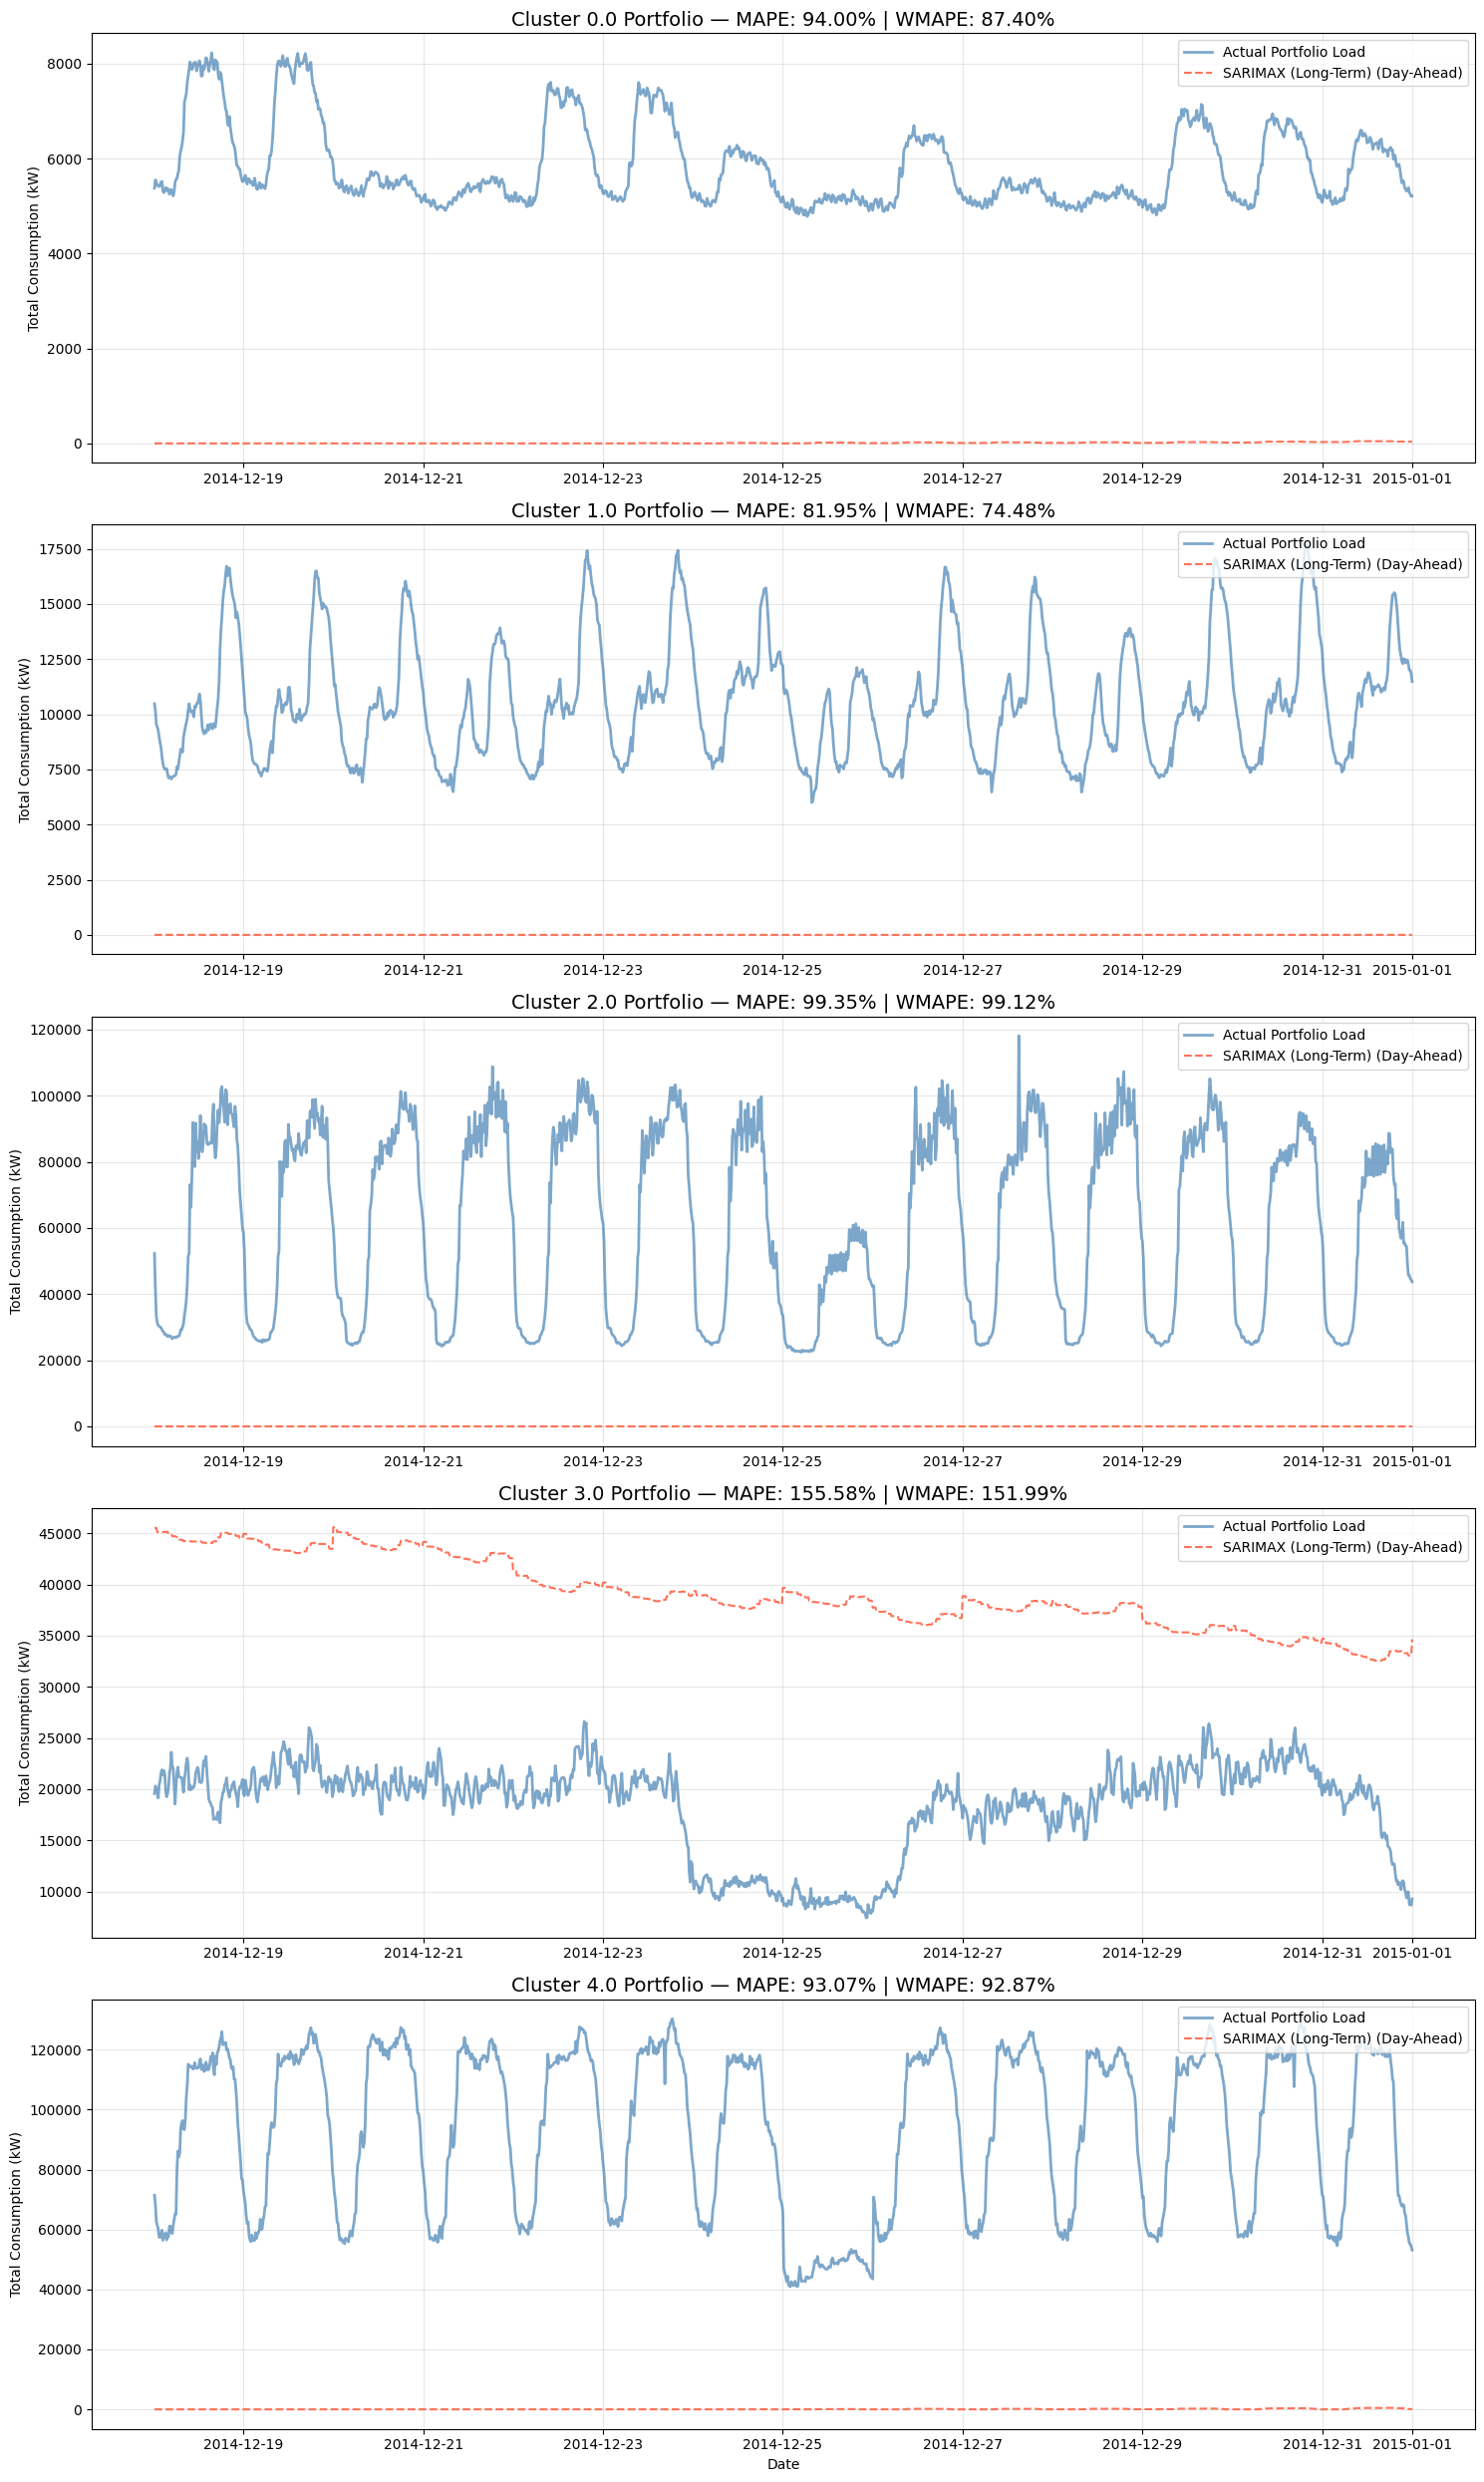

In [6]:
# Visualization for Long-Term results
plot_cluster_portfolio(eval_lt, summary_lt, model_label="SARIMAX (Long-Term)")

In [ ]:
# Perform time-period split analysis
summary_lt = analyze_time_periods(results_lt)
display(summary_lt)

## 4.  Day-Ahead Horizon

In this mode, we provide SARIMAX with historical consumption lags (24h and 1-week back) as exogenous variables. This should significantly improve performance on short-term horizons.

In [ ]:
# RAM CLEANUP
print("Cleaning memory from Long-Term run...")
del train_agg_lt, test_agg_lt, test_raw_lt, models_lt, results_lt, eval_lt, summary_lt
import gc
gc.collect()

# B.1 Prepare Data (Day Ahead)
train_agg_da, test_agg_da, test_raw_da, scalers_da, sw_da, regs_da = preprocess_and_split(df_long, mode='day_ahead')

# B.2 Train Cluster Models
models_da = train_models(train_agg_da, regs_da)

# B.3 Predict & Un-scale
results_da = predict_models(models_da, test_agg_da, test_raw_da, scalers_da, regs_da)

# B.4 Evaluate
eval_da, summary_da = evaluate_models(results_da)
display(summary_da)

# Save Artifacts
save_sarimax_artifacts(models_da, scalers_da, sw_da, regs_da, mode='day_ahead')

Preparing train/test split and scaling (Mode: DAY_AHEAD)...
Scaling individual clients (preventing leakage)...


Scaling Clients: 100%|██████████| 369/369 [00:18<00:00, 19.56it/s]


Aggregating data by Cluster for SARIMAX training...
Training SARIMAX models for 5 clusters...


Training: 100%|██████████| 5/5 [08:31<00:00, 102.35s/it]


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:04<00:00, 86.78it/s] 



Evaluating Portfolio Performance...

--- SARIMAX PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0               48.46            24.71
1.0               49.24             6.29
2.0               84.71            44.82
3.0               16.66            13.71
4.0               16.94            14.19

Global Portfolio MAPE:  43.20%
Global Portfolio WMAPE: 25.44%


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
0.0,48.46,24.71
1.0,49.24,6.29
2.0,84.71,44.82
3.0,16.66,13.71
4.0,16.94,14.19



 SARIMAX (day_ahead) artifacts successfully saved to: /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-electricity/agent/artifacts/sarimax_cluster_day_ahead.pkl


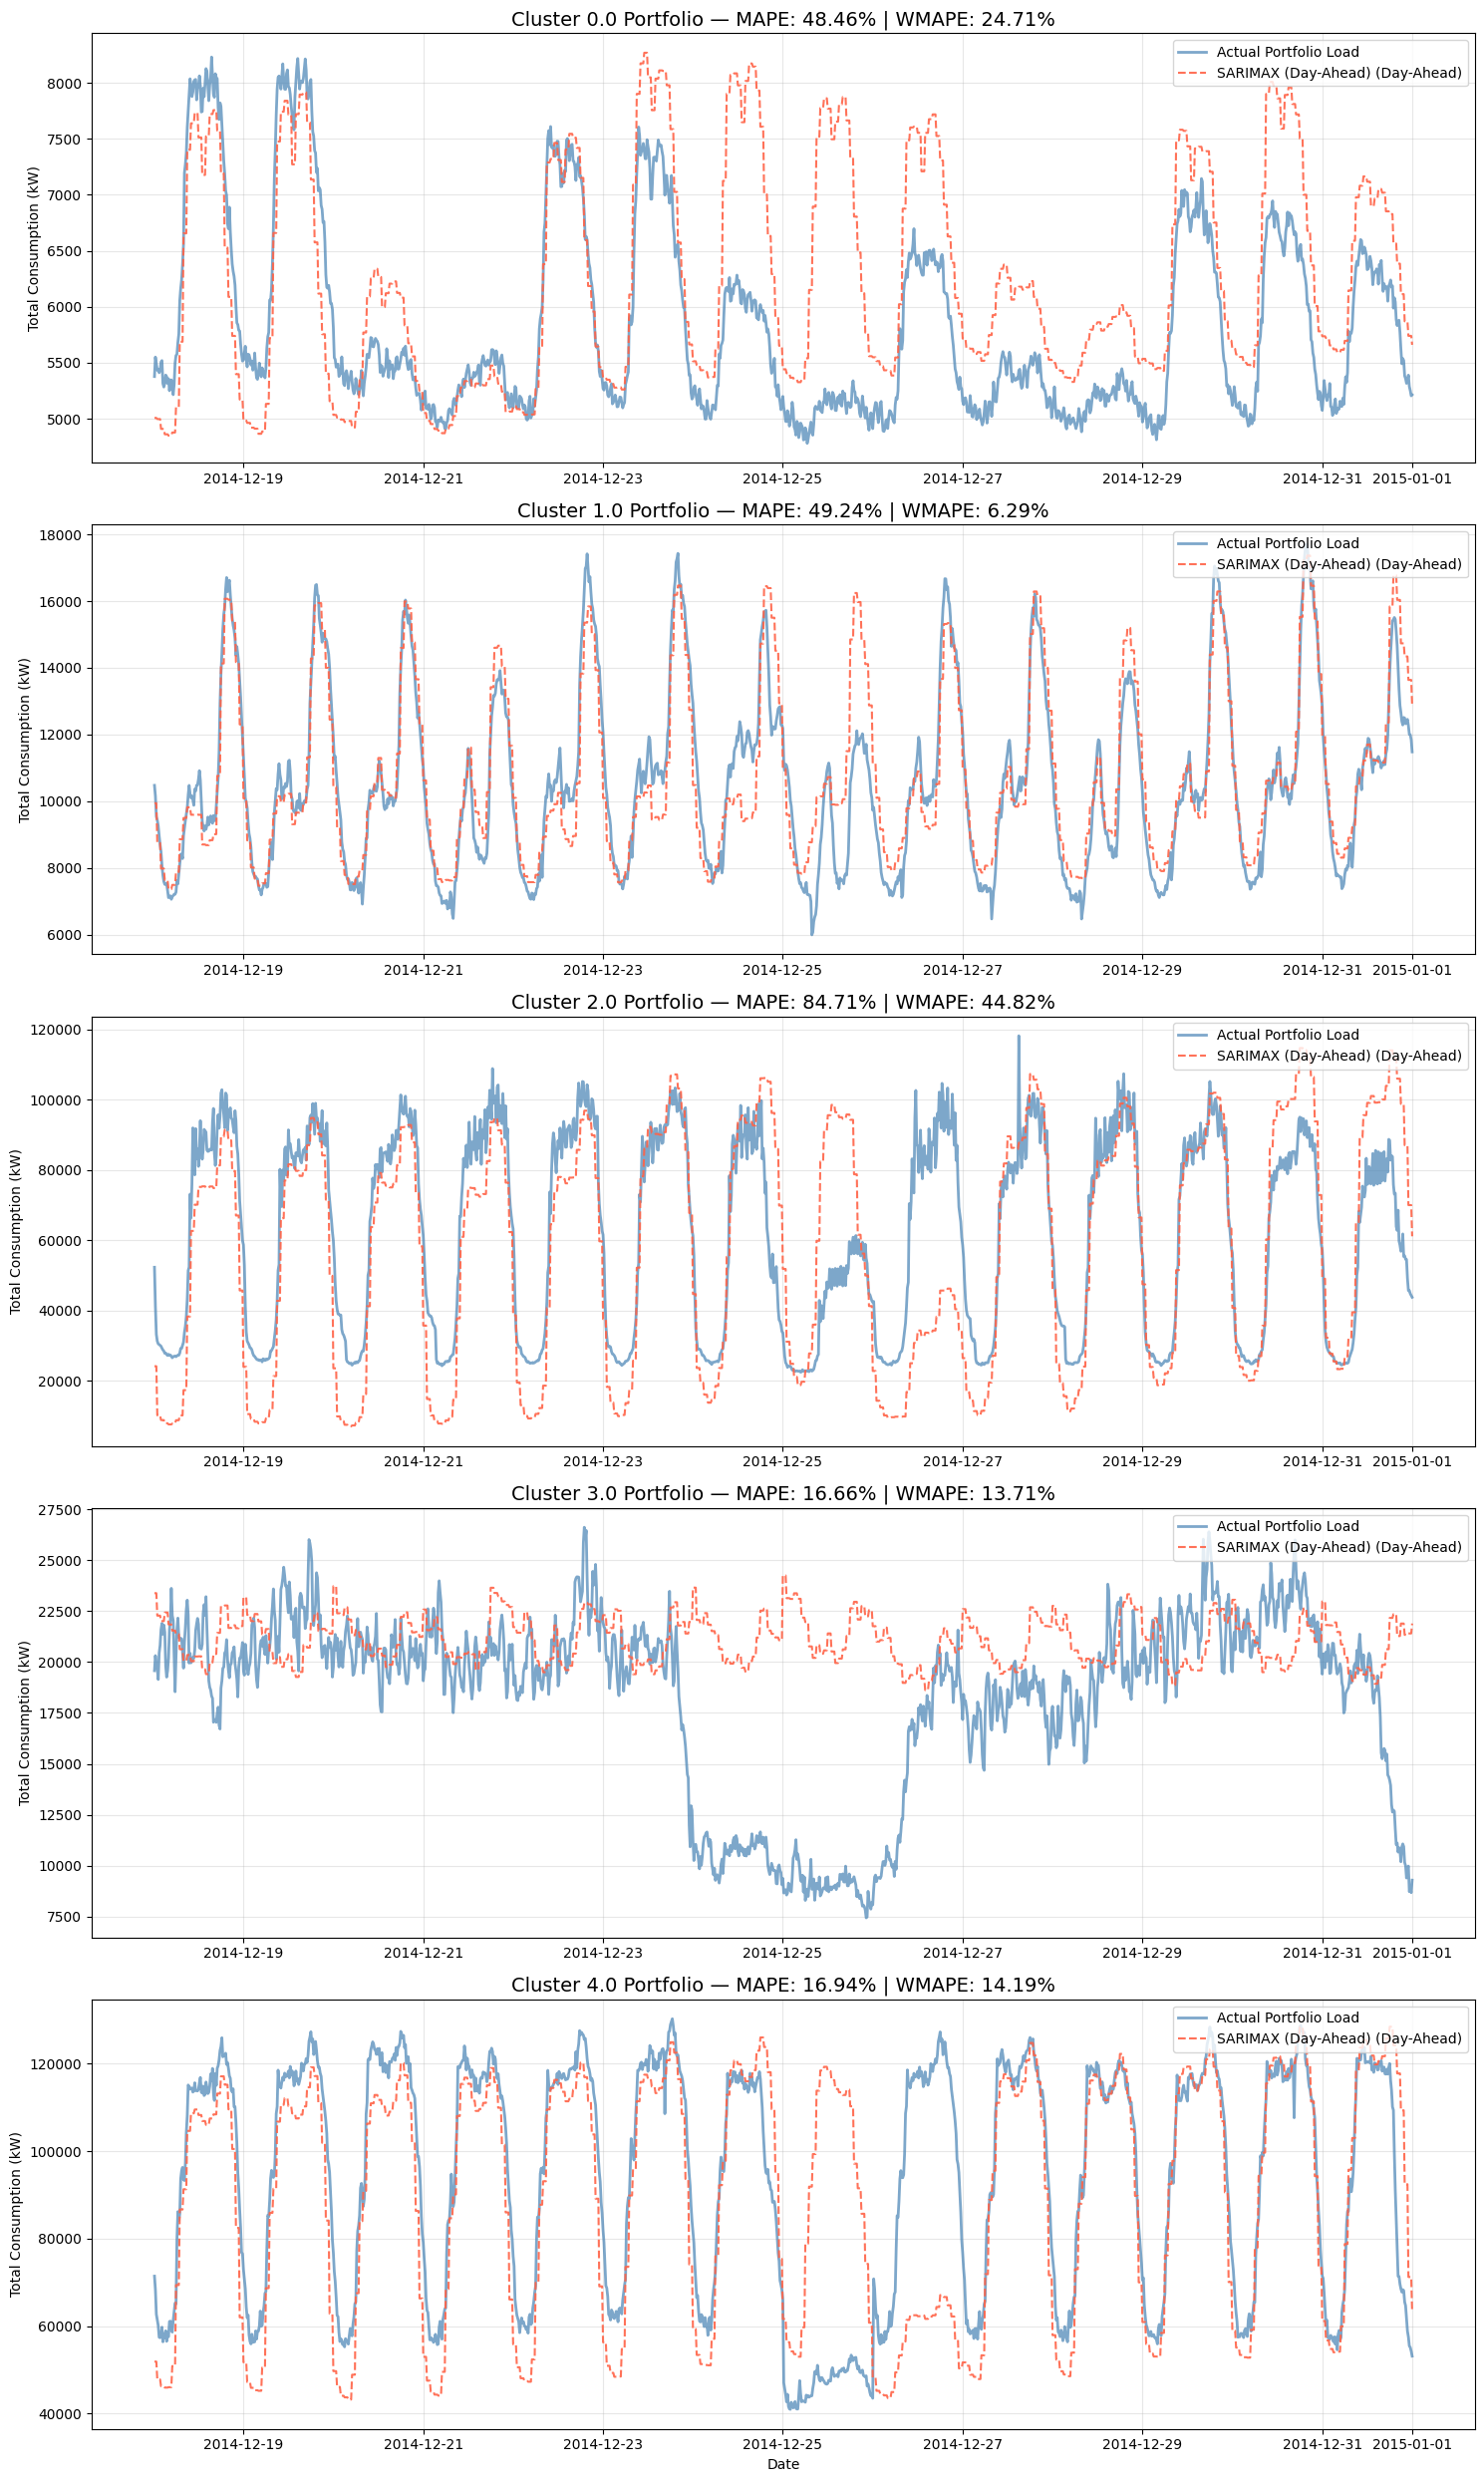

In [8]:
# Visualization for Day-Ahead results
plot_cluster_portfolio(eval_da, summary_da, model_label="SARIMAX (Day-Ahead)")

In [ ]:
# Perform time-period split analysis
summary_lt = analyze_time_periods(results_da)
display(summary_lt)